# Phân tích Thống kê Insight từ Kết quả PrefixSpan (Bản nâng cấp)
Notebook này phân tích các quy luật lây lan kẹt xe (Domino Jams) và ánh xạ chúng ngược lại các Trạm xe buýt thực tế để đưa ra các insight có thể hành động được (Actionable Insights).

In [4]:
import pandas as pd
import numpy as np
import os
import sys
import json
import matplotlib.pyplot as plt
import seaborn as sns
from prefixspan import PrefixSpan

# Thêm đường dẫn project vào sys.path để import helpers
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from app.helpers import sequential_mining, translate_prefixspan_patterns

sns.set_theme(style="whitegrid")

## 1. Load Dữ liệu
Dữ liệu bao gồm các điểm kẹt xe (`black_spot.parquet`) và thông tin trạm xe buýt (`bus_station_data.json`) để ánh xạ địa danh.

In [22]:
jam_path = os.path.join(PROJECT_ROOT, 'data', 'black_spot.parquet')
station_path = os.path.join(PROJECT_ROOT, 'data', '2_silver', 'bus_station_data.json')

if not os.path.exists(jam_path) or not os.path.exists(station_path):
    print("Vui lòng đảm bảo các file dữ liệu tồn tại.")
else:
    jam_df = pd.read_parquet(jam_path)
    with open(station_path, 'r', encoding='utf-8') as f:
        station_data = json.load(f)
    station_df = pd.DataFrame(station_data)
    
    print(f"Đã load {len(jam_df)} điểm kẹt và {len(station_df)} trạm xe buýt.")

jam_df = jam_df.query("inferred_route == '50' or inferred_route == '122' or inferred_route == '30' ")

Đã load 933436 điểm kẹt và 1644 trạm xe buýt.


## 2. Tìm kiếm các Frequent Patterns (Domino Jams)
Chúng ta sẽ chạy PrefixSpan và sau đó "dịch" các tọa độ Zone sang Tên trạm gần nhất.

In [23]:
# 1. Chạy thuật toán mining cơ bản
pattern_df = sequential_mining(jam_df, min_support=20)

# 2. Ánh xạ sang tên trạm (Sử dụng helper từ dự án)
pattern_df = translate_prefixspan_patterns(pattern_df, station_df)

print(f"Tìm thấy {len(pattern_df)} chuỗi lây lan kẹt xe.")
display(pattern_df[['Readable_Pattern', 'Frequency']].head(10))

d:\Bus-Status-Analysis-Prediction\app\helpers.py:111: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  jam_df['date'] = pd.to_datetime(jam_df['realtime']).dt.date


Tìm thấy 6986 chuỗi lây lan kẹt xe.


,Readable_Pattern,Frequency
5493,[Công ty Giấy Mai Lan] ➡️ [Lê Sát],58
6069,[Công ty Giấy Mai Lan] ➡️ [Mầm non Hoa Lư],58
4156,[Trường Marie Curie] ➡️ [Công ty Giấy Mai Lan],56
3659,[Mầm non Hoa Lư] ➡️ [Công ty Giấy Mai Lan],56
3147,[Khách sạn Sofitel] ➡️ [Công ty Giấy Mai Lan],56
4450,[Trường Marie Curie] ➡️ [Mầm non Hoa Lư],56
2616,[Khách sạn Sofitel] ➡️ [Mầm non Hoa Lư],56
6680,[Lê Sát] ➡️ [Mầm non Hoa Lư],55
6290,[Lê Sát] ➡️ [Trường Marie Curie],54
4238,[Trường Marie Curie] ➡️ [Lê Sát],53


## 3. Thống kê Insider: Top trạm "Phát tán" kẹt xe (Root Causes)
Chúng ta sẽ đếm xem trạm nào thường xuyên nằm ở **vị trí bắt đầu** của chuỗi Domino nhất.

C:\Users\nguye\AppData\Local\Temp\ipykernel_3452\606872716.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=source_stats.head(10), x='Frequency', y='Start_Station', palette='Reds_r')


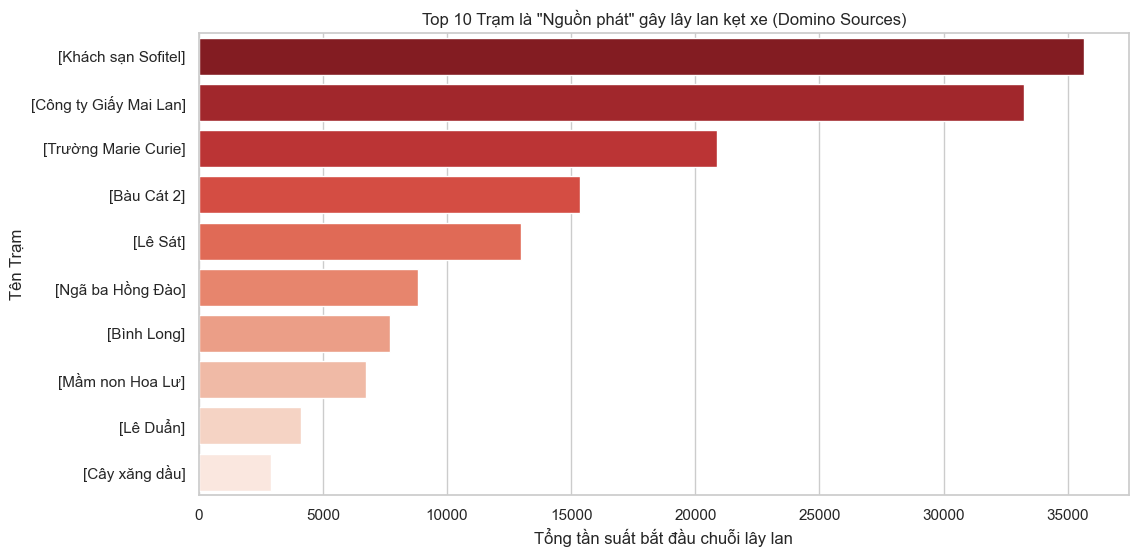

In [24]:
# Tách lấy trạm đầu tiên trong cột Readable_Pattern
pattern_df['Start_Station'] = pattern_df['Readable_Pattern'].apply(lambda x: x.split(' ➡️ ')[0])
pattern_df['End_Station'] = pattern_df['Readable_Pattern'].apply(lambda x: x.split(' ➡️ ')[-1])

source_stats = pattern_df.groupby('Start_Station')['Frequency'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=source_stats.head(10), x='Frequency', y='Start_Station', palette='Reds_r')
plt.title('Top 10 Trạm là "Nguồn phát" gây lây lan kẹt xe (Domino Sources)')
plt.xlabel('Tổng tần suất bắt đầu chuỗi lây lan')
plt.ylabel('Tên Trạm')
plt.show()

## 4. Thống kê Insider: Top trạm "Hứng Chịu" kẹt xe (Bottlenecks)
Đây là những trạm thường xuyên là **vị trí kết thúc** của chuỗi Domino.

C:\Users\nguye\AppData\Local\Temp\ipykernel_3452\1874115025.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sink_stats.head(10), x='Frequency', y='End_Station', palette='Blues_r')


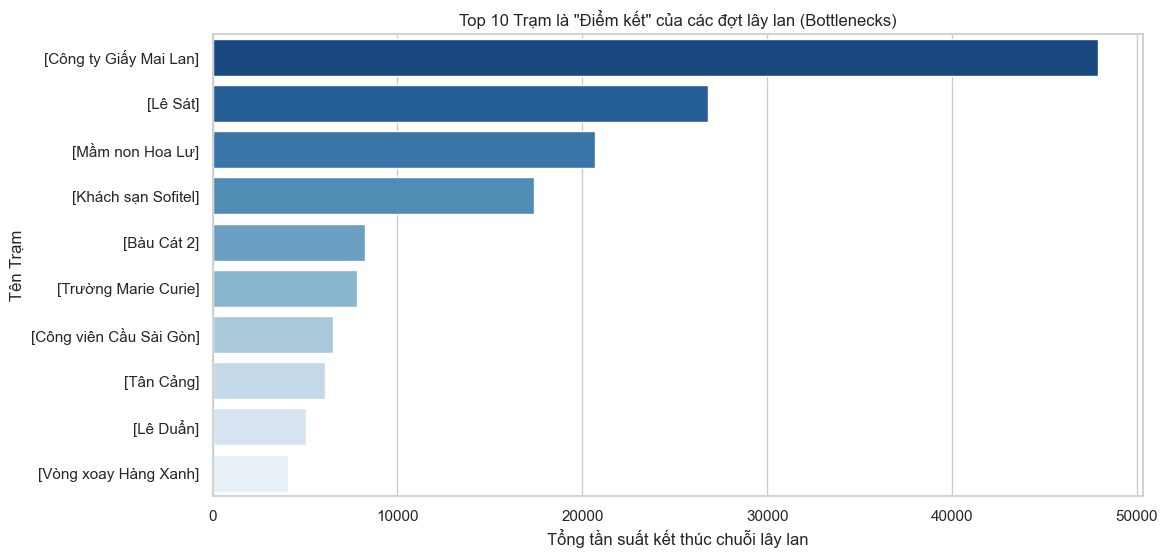

In [25]:
sink_stats = pattern_df.groupby('End_Station')['Frequency'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=sink_stats.head(10), x='Frequency', y='End_Station', palette='Blues_r')
plt.title('Top 10 Trạm là "Điểm kết" của các đợt lây lan (Bottlenecks)')
plt.xlabel('Tổng tần suất kết thúc chuỗi lây lan')
plt.ylabel('Tên Trạm')
plt.show()

## 5. Ma trận Xác suất Chuyển trạng thái (Transition Probability)
Nếu một chiếc xe buýt gặp kẹt xe tại Trạm A, xác suất nó sẽ tiếp tục kẹt ở Trạm B kế tiếp là bao nhiêu?

In [26]:
transitions = []
for _, row in pattern_df.iterrows():
    stations = row['Readable_Pattern'].split(' ➡️ ')
    freq = row['Frequency']
    for i in range(len(stations) - 1):
        transitions.append({'From': stations[i], 'To': stations[i+1], 'Freq': freq})

trans_df = pd.DataFrame(transitions).groupby(['From', 'To'])['Freq'].sum().reset_index()
total_from = trans_df.groupby('From')['Freq'].sum().rename('Total_Freq')
trans_df = trans_df.merge(total_from, on='From')
trans_df['Prob'] = (trans_df['Freq'] / trans_df['Total_Freq'] * 100).round(2)

print("Top 10 'Cặp bài trùng' lây lan kẹt xe có xác suất cao nhất:")
display(trans_df.sort_values(['Prob', 'Freq'], ascending=False).head(10))

Top 10 'Cặp bài trùng' lây lan kẹt xe có xác suất cao nhất:


,From,To,Freq,Total_Freq,Prob
291,[Quán Vườn Dừa],[Ngã tư Tô Ngọc Vân - Phạm Văn Đồng],44,44,100.00
310,[Sở xây Dựng],[Công ty Giấy Mai Lan],21,21,100.00
382,[Đường số 9],[Đầu công viên Gia Định],21,21,100.00
54,[Bến xe Văn Thánh],[Công ty Giấy Mai Lan],179,246,72.76
147,[Hội trường Thành ủy],[Công ty Giấy Mai Lan],199,311,63.99
314,[TTTM Sài Gòn],[Mầm non Hoa Lư],285,458,62.23
361,[Vòng xoay Lăng Cha Cả],[Quán Vườn Dừa],23,43,53.49
380,[Đường số 20],[Ngã tư Tô Ngọc Vân - Phạm Văn Đồng],23,46,50.00
381,[Đường số 20],[Đường 30],23,46,50.00
289,[Ngã tư Tô Ngọc Vân - Phạm Văn Đồng],[Vòng xoay Lăng Cha Cả],21,42,50.00


## 6. Kết luận và Kiến nghị
Dựa trên các phân tích thống kê trên, chúng ta rút ra các insight quan trọng:

1. **Xác định Root Cause**: Các trạm trong biểu đồ **"Nguồn phát"** (Mục 3) cần được ưu tiên bố trí lực lượng điều tiết hoặc giải tỏa hành lang ngay khi có tín hiệu kẹt xe nhẹ, vì chúng có xác suất cao gây ra hiệu ứng domino cho toàn tuyến.
2. **Hành lang trọng điểm**: Các cặp trạm trong **Ma trận chuyển trạng thái** (Mục 5) với xác suất > 50% cho thấy sự liên kết cực kỳ chặt chẽ về mặt giao thông. Nếu kẹt ở trạm A, gần như chắc chắn xe sẽ kẹt ở trạm B.
3. **Tối ưu hóa Điều độ**: Dispatcher có thể sử dụng các con số xác suất này để ra quyết định "cắt chuyến" hoặc "quay đầu" sớm trước khi xe buýt đi vào vùng lây lan diện rộng.